In [3]:
# PROJETO: Análise de Imóveis - Samambaia
# Objetivo:
# Explorar dados reais de imóveis e gerar insights sobre preços,
# metragem e características dos imóveis.
# ========================================= #
# 1. Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:

# 2. Carregando os dados
import os

caminho = os.path.join("..", "data", "imoveis_anapolis_sem_limpeza.csv")
df = pd.read_csv(caminho)

In [5]:

# 3. Entendimento inicial dos dados
print(df.head())
print(df.columns)
print(df.info())
print(df.describe())

                                         endereco    preco  quartos metragem  \
0                     Rua 11, VILA GOIS, ANAPOLIS  890.000        3   199 m²   
1            AVENIDA PATRIARCA, LOURDES, ANAPOLIS  250.000        2    41 m²   
2  Avenida Mirage, RESIDENCIAL ITATIAIA, ANAPOLIS  230.000        2    50 m²   
3           AVENIDA FABRIL, VILA FABRIL, ANAPOLIS  280.000        2    50 m²   
4                Rua D, ANDRACEL CENTER, ANAPOLIS  230.000        2    42 m²   

     vagas  
0  3 Vagas  
1   1 Vaga  
2   1 Vaga  
3   1 Vaga  
4   1 Vaga  
Index(['endereco', 'preco', 'quartos', 'metragem', 'vagas'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   endereco  333 non-null    object
 1   preco     333 non-null    object
 2   quartos   333 non-null    int64 
 3   metragem  333 non-null    object
 4   vagas     315 non-null    o

In [4]:

# ========================================= #
# Perguntas iniciais:
# - Quantos imóveis existem?
# - Existem valores nulos?
# - Qual a faixa de preços?
# ========================================= #


In [5]:

# 4. Limpeza de dados
df.isnull().sum()

# Removendo valores nulos
df = df.dropna().copy()

# Tratamento da coluna metragem (remover "m²")
df['metragem'] = (
    df['metragem']
    .str.replace(" m²", "", regex=False)
    .astype(float)
)

# Tratamento da coluna vagas (remover "Vagas" / "Vaga")
df['vagas'] = (
    df['vagas']
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

# Garantindo tipo numérico do preço
df['preco'] = pd.to_numeric(df['preco'], errors='coerce')


Preço médio: 407.9585400696864
Metragem média: 88.6952380952381
Média de quartos: 2.5682539682539685


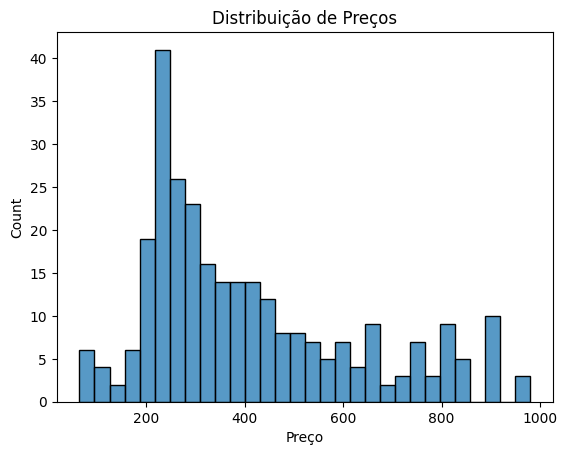

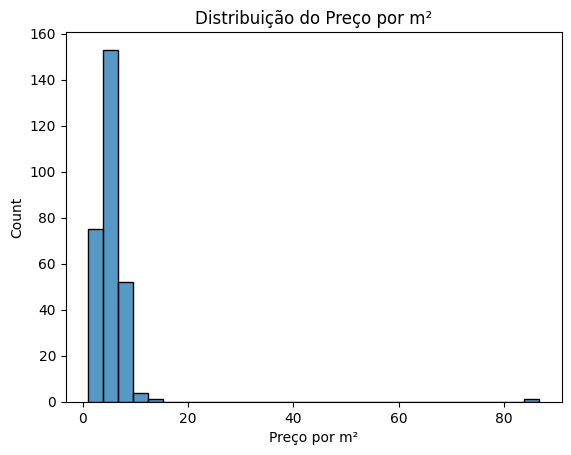

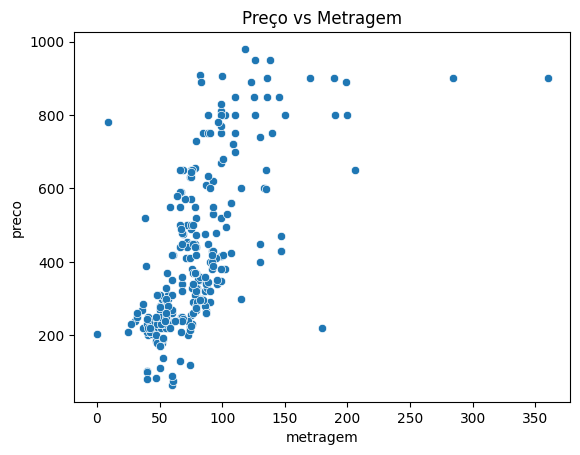

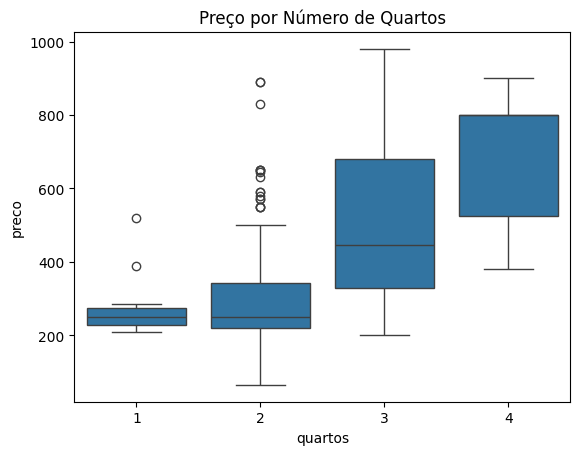

In [6]:

# Análises básicas
print("Preço médio:", df['preco'].mean())
print("Metragem média:", df['metragem'].mean())
print("Média de quartos:", df['quartos'].mean())

# 6. Criando nova variável (ESSENCIAL)
df['preco_m2'] = df['preco'] / df['metragem']
df.head()

# 7. Visualizações
# Distribuição de preços
plt.figure()
sns.histplot(df['preco'], bins=30)
plt.title("Distribuição de Preços")
plt.xlabel("Preço")
plt.show()

# Preço por m²
plt.figure()
sns.histplot(df['preco_m2'], bins=30)
plt.title("Distribuição do Preço por m²")
plt.xlabel("Preço por m²")
plt.show()

# Relação metragem vs preço
plt.figure()
sns.scatterplot(x='metragem', y='preco', data=df)
plt.title("Preço vs Metragem")
plt.show()

# Quartos vs preço
plt.figure()
sns.boxplot(x='quartos', y='preco', data=df)
plt.title("Preço por Número de Quartos")
plt.show()


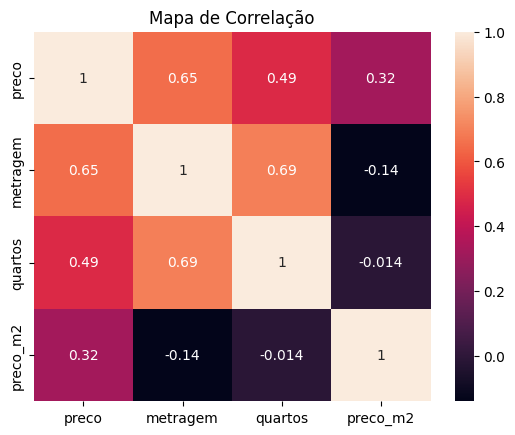

,endereco,preco,quartos,metragem,vagas,preco_m2
298,"Rua AVELAR, VILA SANTA ISABEL, ANAPOLIS",205.0,2,0.0,1,inf
262,"AVENIDA UNIVERSITARIA, MARACANA, ANAPOLIS",780.0,3,9.0,2,86.666667
187,"Rua DOUTOR VITAL BRASIL, CIDADE UNIVERSITARIA,...",520.0,1,38.0,1,13.684211
17,"Rua 11, JK PARQUE INDUSTRIAL NOVA CAPITAL, ANA...",910.0,3,82.0,1,11.097561
208,"Rua CONEGO RAMIRO, JUNDIAI, ANAPOLIS",890.0,2,83.0,2,10.722892
299,"Rua DOUTOR VITAL BRASIL, CIDADE UNIVERSITARIA,...",390.0,1,39.0,1,10.000000
276,"AVENIDA MADRE MARIA DOS ANJOS, JUNDIAI, ANAPOLIS",650.0,2,66.0,1,9.848485
117,"Rua VITOR DE AZEVEDO, JUNDIAI, ANAPOLIS",550.0,2,58.0,1,9.482759
132,"AVENIDA BRASIL, CIDADE UNIVERSITARIA, ANAPOLIS",650.0,2,69.0,1,9.420290
255,"Rua VITOR DE AZEVEDO, JUNDIAI, ANAPOLIS",730.0,3,79.0,2,9.240506


In [7]:

# ==================== AVANÇADO ===================== #
# 8. Correlação
corr = df[['preco', 'metragem', 'quartos', 'preco_m2']].corr()
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Mapa de Correlação")
plt.show()

# 9. Identificando oportunidades
# Imóveis com menor preço por m² (possíveis boas oportunidades)
df.sort_values(by='preco_m2').head(10)

# Imóveis mais caros por m²
df.sort_values(by='preco_m2', ascending=False).head(10)
# ========================================= #
